In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
%pip install kagglehub
import kagglehub

# Download latest version
path = kagglehub.dataset_download("atharvaingle/crop-recommendation-dataset")

print("Path to dataset files:", path)

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Path to dataset files: C:\Users\abhis\.cache\kagglehub\datasets\atharvaingle\crop-recommendation-dataset\versions\1


In [ ]:
df=pd.read_csv(path+"/Crop_recommendation.csv")
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [ ]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [ ]:
df.label.value_counts(), len(df.label.unique())

(label
 rice           100
 maize          100
 chickpea       100
 kidneybeans    100
 pigeonpeas     100
 mothbeans      100
 mungbean       100
 blackgram      100
 lentil         100
 pomegranate    100
 banana         100
 mango          100
 grapes         100
 watermelon     100
 muskmelon      100
 apple          100
 orange         100
 papaya         100
 coconut        100
 cotton         100
 jute           100
 coffee         100
 Name: count, dtype: int64,
 22)

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['label_en']=le.fit_transform(df.label)

In [ ]:
le.classes_

array(['apple', 'banana', 'blackgram', 'chickpea', 'coconut', 'coffee',
       'cotton', 'grapes', 'jute', 'kidneybeans', 'lentil', 'maize',
       'mango', 'mothbeans', 'mungbean', 'muskmelon', 'orange', 'papaya',
       'pigeonpeas', 'pomegranate', 'rice', 'watermelon'], dtype=object)

In [ ]:
le

LabelEncoder()

In [ ]:
new_df=df.drop(['label'],axis=1)

In [ ]:
new_df.head()

,N,P,K,temperature,humidity,ph,rainfall,label_en
0,90,42,43,20.879744,82.002744,6.502985,202.935536,20
1,85,58,41,21.770462,80.319644,7.038096,226.655537,20
2,60,55,44,23.004459,82.320763,7.840207,263.964248,20
3,74,35,40,26.491096,80.158363,6.980401,242.864034,20
4,78,42,42,20.130175,81.604873,7.628473,262.717340,20


In [ ]:
le.inverse_transform([1])

array(['banana'], dtype=object)

<Axes: >

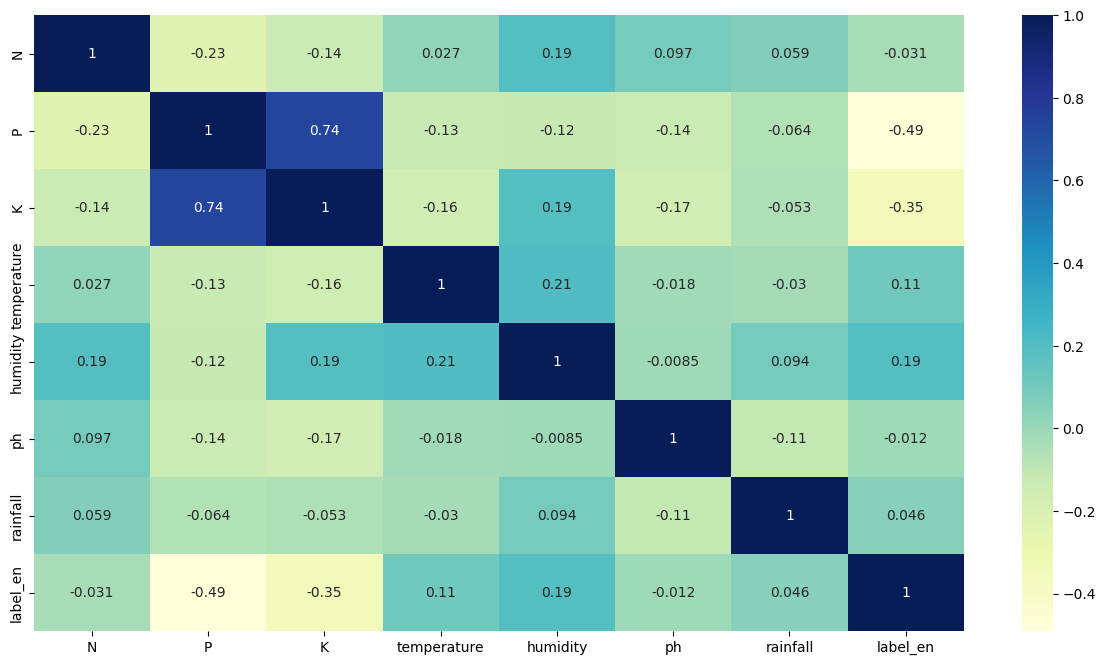

In [ ]:
plt.figure(figsize=(15,8))
sns.heatmap(new_df.corr(),annot=True,cmap="YlGnBu")

In [ ]:
new_df.head()


,N,P,K,temperature,humidity,ph,rainfall,label_en
0,90,42,43,20.879744,82.002744,6.502985,202.935536,20
1,85,58,41,21.770462,80.319644,7.038096,226.655537,20
2,60,55,44,23.004459,82.320763,7.840207,263.964248,20
3,74,35,40,26.491096,80.158363,6.980401,242.864034,20
4,78,42,42,20.130175,81.604873,7.628473,262.717340,20


In [ ]:
x,y=new_df.drop(['label_en'],axis=1),new_df['label_en']


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test, y_train,y_test=train_test_split(x,y,test_size=0.2)

In [ ]:
train_data=x_train.join(y_train)
test_data=x_test.join(y_test)
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train_s=sc.fit_transform(x_train)
x_test_s=sc.transform(x_test)

In [ ]:
x_test,x_test_s

(        N    P    K  temperature   humidity        ph    rainfall
 2088   82   46   41    23.325013  79.796094  6.581694  187.309615
 1221   38  132  197    20.420948  81.541850  5.931102   66.930657
 802    38   60   20    29.848231  60.638726  7.491217   46.804526
 195    90   57   24    18.928519  72.800861  6.158860   82.341629
 1149    5   19   25    27.351106  54.439451  6.441328   96.277925
 ...   ...  ...  ...          ...        ...       ...         ...
 1470  115   12   52    27.514922  94.962187  6.685553   21.017964
 858    26   68   24    28.048496  64.076919  7.504931   37.158250
 271    34   71   79    17.927806  15.856229  7.728998   74.638728
 30     73   57   41    21.446540  84.943760  5.824709  272.201720
 1142   34   38   31    35.377756  45.581100  6.454045   97.415864
 
 [440 rows x 7 columns],
 array([[ 0.87213582, -0.21650626, -0.13425748, ...,  0.38838635,
          0.14297057,  1.52728433],
        [-0.33164634,  2.41692252,  2.98988305, ...,  0.46582394,
 

In [ ]:
x_train_s_df = pd.DataFrame(x_train_s, columns=x_train.columns, index=x_train.index)
train_data_s = x_train_s_df.join(y_train)

x_test_s_df = pd.DataFrame(x_test_s, columns=x_test.columns, index=x_test.index)
test_data_s = x_test_s_df.join(y_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(x_train_s,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [ ]:
lr.score(x_test_s,y_test)

0.975

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rfc=RandomForestClassifier()
rfc.fit(x_train_s,y_train)
rfc.score(x_test_s,y_test)

1.0

In [ ]:
%pip install xgboost
from xgboost import XGBClassifier

xgb = XGBClassifier()
xgb.fit(x_train_s_df, y_train)

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [ ]:
%pip install lightgbm
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier()
lgbm.fit(x_train_s_df, y_train)

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   --------------------- ------------------ 0.8/1.5 MB 8.8 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 5.0 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000563 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1334
[LightGBM] [Info] Number of data points in the train set: 1760, number of used features: 7
[LightGBM] [Info] Start training from score -3.078620
[LightGBM] [Info] Start training from score -3.129264
[LightGBM] [Info] Start training from score -3.042252
[LightGBM] [Info] Start training from score -3.007161
[LightGBM] [Info] Start training from score -3.116360
[LightGBM] [Info] Start training from score -3.042252
[LightGBM] [Info] Start tra

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [ ]:
%pip install catboost
from catboost import CatBoostClassifier

cat = CatBoostClassifier(verbose=0)
cat.fit(x_train_s_df, y_train)

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
    --------------------------------------- 1.3/101.7 MB 4.8 MB/s eta 0:00:22
    --------------------------------------- 2.1/101.7 MB 5.0 MB/s eta 0:00:20
   - -------------------------------------- 2.6/101.7 MB 3.7 MB/s eta 0:00:27
   - -------------------------------------- 3.4/101.7 MB 4.3 MB/s eta 0:00:24
   - -------------------------------------- 4.7/101.7 MB 4.2 MB/s eta 0:00:24
   - -------------------------------------- 5.0/101.7 MB 4.1 MB/s eta 0:00:24
   -- ------------------------------------- 6.0/101.7 MB 4.0 MB/s eta 0:00:24
   -- ------------------------------------- 6.8/101.7 MB 4.0 MB/s eta 0:00:24
   --- ------------------------------------ 7.9/101.7 MB 4.0 MB/s eta 0:00:24
   --- ------------------------------------ 8.7/101.7 MB 4.0 MB/s eta 0:00:24


CatBoostClassifier(verbose=0)

In [ ]:
xgb_preds = xgb.predict(x_test_s_df)
lgbm_preds = lgbm.predict(x_test_s_df)
cat_preds = cat.predict(x_test_s_df)

# Ensure all predictions are 1D arrays
if xgb_preds.ndim == 2 and xgb_preds.shape[1] == 1:
    xgb_preds = xgb_preds.ravel()
if lgbm_preds.ndim == 2 and lgbm_preds.shape[1] == 1:
    lgbm_preds = lgbm_preds.ravel()
if cat_preds.ndim == 2 and cat_preds.shape[1] == 1:
    cat_preds = cat_preds.ravel()

final_pred = (0.4 * xgb_preds + 0.3 * lgbm_preds + 0.3 * cat_preds)
# Round to the nearest integer and convert to int type for class labels
final_pred = np.round(final_pred).astype(int)

In [ ]:
print("XGB:", xgb.score(x_test_s_df,y_test))
print("LGBM:", lgbm.score(x_test_s_df, y_test))
print("CAT:", cat.score(x_test_s_df,y_test))

XGB: 0.9977272727272727
LGBM: 0.9977272727272727
CAT: 0.9977272727272727


In [ ]:
print(f'Accuracy of ensemble prediction: {(final_pred == y_test).mean():.4f}')

Accuracy of ensemble prediction: 0.9977


In [ ]:
le.inverse_transform(final_pred)

array(['jute', 'grapes', 'lentil', 'maize', 'mango', 'coconut',
       'chickpea', 'mothbeans', 'grapes', 'mungbean', 'chickpea',
       'coconut', 'grapes', 'jute', 'jute', 'watermelon', 'watermelon',
       'coffee', 'cotton', 'watermelon', 'grapes', 'pigeonpeas',
       'watermelon', 'banana', 'apple', 'jute', 'maize', 'muskmelon',
       'jute', 'papaya', 'pomegranate', 'pigeonpeas', 'grapes', 'coconut',
       'maize', 'maize', 'grapes', 'mothbeans', 'mungbean', 'mungbean',
       'lentil', 'mothbeans', 'papaya', 'banana', 'muskmelon',
       'blackgram', 'jute', 'chickpea', 'mothbeans', 'pigeonpeas',
       'banana', 'muskmelon', 'kidneybeans', 'papaya', 'banana',
       'pomegranate', 'mango', 'grapes', 'rice', 'rice', 'maize', 'apple',
       'coconut', 'pomegranate', 'pomegranate', 'mothbeans', 'papaya',
       'mungbean', 'jute', 'rice', 'kidneybeans', 'apple', 'banana',
       'coconut', 'maize', 'jute', 'banana', 'pomegranate', 'banana',
       'grapes', 'kidneybeans', 'jut

In [ ]:
import pickle

# Save the CatBoost model (highest accuracy at 99.77%)
with open('best_model.pkl', 'wb') as f:
    pickle.dump(cat, f)

# Save the StandardScaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(sc, f)

# Save the LabelEncoder
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print("Best model (CatBoost) saved to best_model.pkl")
print("StandardScaler saved to scaler.pkl")
print("LabelEncoder saved to label_encoder.pkl")

Best model (CatBoost) saved to best_model.pkl
StandardScaler saved to scaler.pkl
LabelEncoder saved to label_encoder.pkl


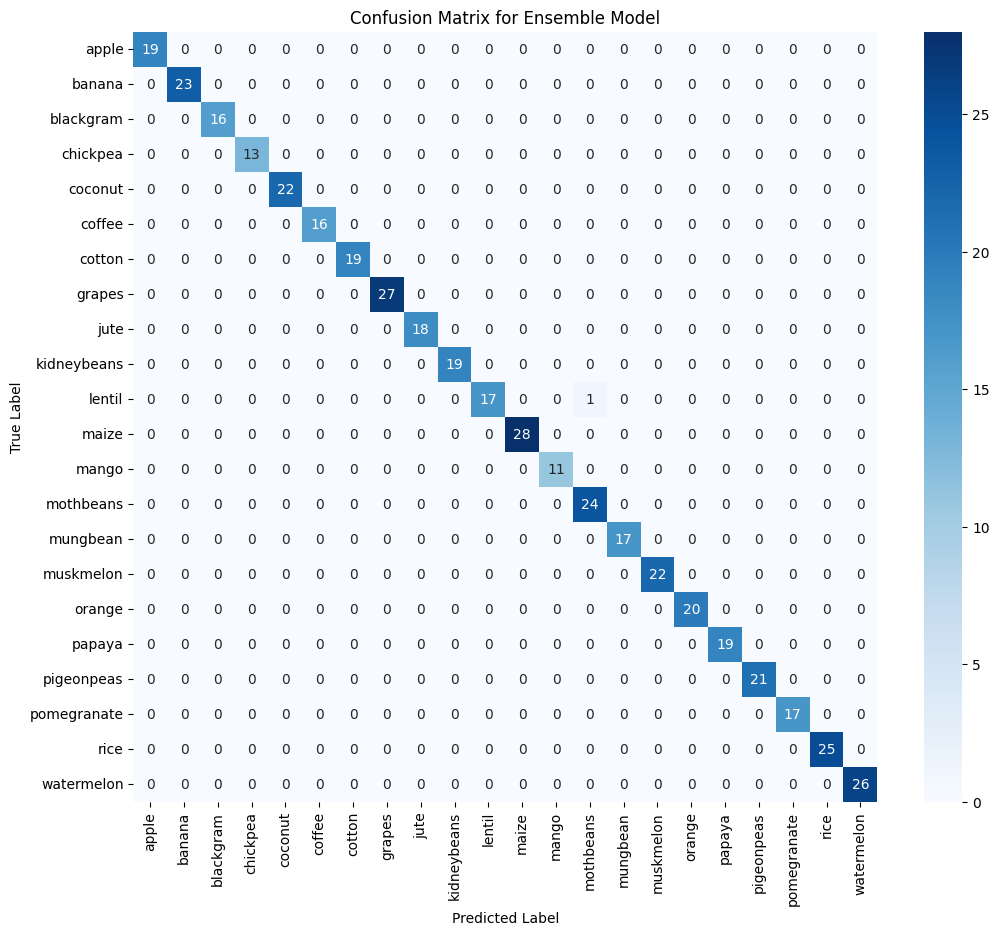

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get the confusion matrix
cm = confusion_matrix(y_test, final_pred)

# Get class labels for plotting
class_labels = le.inverse_transform(np.arange(len(le.classes_)))

# Plot the confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Ensemble Model')
plt.show()